In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

In [2]:
loaded__identified_data_npy = np.load('identified_eigdata.npy', allow_pickle=True).item()
Phi_id = loaded__identified_data_npy['Phi_id']
freq_id = loaded__identified_data_npy['freq_id']
ind_d = loaded__identified_data_npy['ind_d']

print(Phi_id.shape)

loaded_modelled_data_npy = np.load('modelled_eigdata.npy', allow_pickle=True).item()
Phi_M = loaded_modelled_data_npy['Phi_m']
freq_m = loaded_modelled_data_npy['freq_m']

print(Phi_M.shape)

Phi_m = Phi_M[ind_d, :]
Phi_m = Phi_m / np.linalg.norm(Phi_m, axis=0)
print(Phi_m.shape)

(35, 10)
(285, 255)
(35, 255)


In [3]:
n_modes = len(freq_id)

Text(0, 0.5, 'Mode Number')

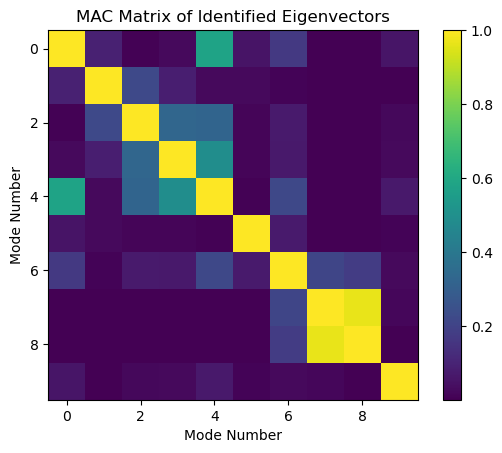

In [4]:
# Calculate and plot the global MAC matrix
MAC = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        MAC[i, j] = (np.abs(Phi_id[:, i].conj().T @ Phi_id[:, j]))**2 / ((Phi_id[:, i].conj().T @ Phi_id[:, i]) * (Phi_id[:, j].conj().T @ Phi_id[:, j]))

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = plt.imshow(MAC)
plt.colorbar(fig)
plt.title('MAC Matrix of Identified Eigenvectors')
plt.xlabel('Mode Number')
plt.ylabel('Mode Number')

# Attempt to plot MAC for identified and modelled modes

In [ ]:
Phi_m = Phi_m / np.linalg.norm(Phi_m, axis=0)

(35, 255)


In [6]:
MAC = np.zeros((Phi_id.shape[1] + 5, Phi_id.shape[1]))   # Initialize MAC matrix
for i in range(Phi_id.shape[1] + 5):                     # Index over computed modes (larger)
    for j in range(Phi_id.shape[1]):                     # Index over identified modes
        numerator = np.abs(np.conj(Phi_m[:, i]) @ Phi_id[:, j])**2
        denominator = (np.conj(Phi_m[:, i]) @ Phi_m[:, i]) * (np.conj(Phi_id[:, j]) @ Phi_id[:, j])
        MAC[i, j] = numerator / denominator

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = px.imshow(MAC)
fig.show()

In [ ]:
# Calculate and plot the global MAC matrix
MAC = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        MAC[i, j] = (np.abs(Phi_id[:, i].conj().T @ Phi_id[:, j]))**2 / ((Phi_id[:, i].conj().T @ Phi_id[:, i]) * (Phi_id[:, j].conj().T @ Phi_id[:, j]))

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = px.imshow(MAC)
fig.show()

In [10]:
print(freq_m)

[4.10060885e-01 1.43637989e+00 3.01589191e+00 4.81198731e+00
 7.50467179e+00 7.84150934e+00 7.98445841e+00 9.88940099e+00
 1.08189657e+01 1.08746637e+01 1.87830191e+01 2.42778123e+01
 2.55229546e+01 2.88224366e+01 2.92801706e+01 2.96909370e+01
 4.49474556e+01 4.63672526e+01 4.80240509e+01 4.81547525e+01
 4.96700356e+01 5.58543678e+01 5.76483714e+01 6.38062284e+01
 6.81943303e+01 7.18316909e+01 7.19553027e+01 7.20149759e+01
 7.43831994e+01 7.91023174e+01 7.92529704e+01 8.88248193e+01
 8.94899744e+01 9.19344701e+01 9.27918969e+01 9.29918438e+01
 9.41818894e+01 9.61063432e+01 9.76976391e+01 9.83915239e+01
 1.01930273e+02 1.07748752e+02 1.13339574e+02 1.23176377e+02
 1.27505766e+02 1.32031931e+02 1.37645850e+02 1.54743675e+02
 1.57314340e+02 1.57468836e+02 1.60541456e+02 1.65163300e+02
 1.72446363e+02 1.75369539e+02 1.81015240e+02 1.82966344e+02
 1.86176134e+02 1.90521987e+02 1.94094121e+02 2.01476655e+02
 2.13922426e+02 2.16790669e+02 2.17992189e+02 2.31895417e+02
 2.33983098e+02 2.347119

In [ ]:
freqs_model = np.array([0.27, 1.22, 2.47, 4.64, 6.31, 8.83])
df_freqs = pd.DataFrame({'Modelled Frequency': freqs_model, 'Identified Frequency': freq_id})
df_freqs['error %'] = np.round(np.abs(df_freqs['Modelled Frequency'] - df_freqs['Identified Frequency']) / df_freqs['Modelled Frequency'] * 100, 2)

ValueError: All arrays must be of the same length

In [ ]:
df_freqs

,Modelled Frequency,Identified Frequency,error %
0,0.27,0.32,18.52
1,1.22,1.03,15.57
2,2.47,3.08,24.70
3,4.64,4.76,2.59
4,6.31,10.93,73.22
5,8.83,13.60,54.02
